# Character types: archetype + social class × abstractness

Joins Sonnet's `character_type` task (per-character archetypes + social_class) with the social_network task's per-character descriptions. Two priorities for Ch5:

- **P1**: Does char description abstractness track the Pavel idealist→synthesis→anti-idealist axis at the archetype level?
- **P2**: Does the titled_nobility vs untitled_gentry split (which qwen's tags couldn't surface in nb15) show meaningful diachronic structure?

Then P3 (within-archetype concretization across centuries) and P4 (archetype × plot_genre cross-tab).

Data prep: 1,391 texts × ~52 chars/text = 73K characters. Per-character abstractness from `score_psg` over (descriptions + intro_text + notes), negated so + = abstract. Cached at `data/social_networks/character_types_scored.csv`.

In [1]:
import os
import pandas as pd
import numpy as np
import plotnine as p9
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from collections import Counter

plt.rcParams['figure.dpi'] = 110
DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')

ch = pd.read_csv('../data/social_networks/character_types_scored.csv')
ch['archetypes'] = ch['archetypes'].fillna('').apply(lambda s: s.split('|') if s else [])
ch = ch[ch['char_abs'].notna() & ch['year'].notna()].copy()
ch['year'] = ch['year'].astype(int)
ch['century'] = (ch['year'] // 100 * 100).astype(int)
print(f'Characters with abs + year: {len(ch):,}, texts: {ch["source"].nunique():,}')
print(f'Year range: {ch["year"].min()}–{ch["year"].max()}')
print(f'Century distribution:')
print(ch.groupby('century').size().to_string())

Characters with abs + year: 71,764, texts: 1,370
Year range: 1477–2011
Century distribution:
century
1400      653
1500     6107
1600    17808
1700    13372
1800    12928
1900    20298
2000      598


## P1. Char description abstractness × archetype on the Pavel axis

Hypothesis: idealist archetypes (beautiful_soul, exceptional_being, persecuted_innocent, pharmakos) have most abstract descriptions; anti-idealist archetypes (picaro, fallible_everyman) have most concrete; synthesis archetypes (fallible_virtuous, innocent_child) in between.

Multi-label: explode characters to (character × archetype) rows, so each character contributes to all archetypes it carries.

Exploded char×archetype rows: 74,457

Archetype mean abstractness (n>=200, sorted by abs):
          archetype      pavel_axis    n  mean_abs    se
     beautiful_soul        idealist 2413     0.397 0.010
    reformed_sinner       synthesis  518     0.387 0.021
             mentor       synthesis 6539     0.365 0.006
  exceptional_being        idealist 2141     0.342 0.010
             tyrant   anti_idealist 5286     0.318 0.007
             alazon frye_structural 9473     0.312 0.005
             suitor       synthesis 2586     0.309 0.008
  fallible_virtuous       synthesis 1417     0.305 0.012
              rival   anti_idealist 1156     0.303 0.013
               rake   anti_idealist 1464     0.290 0.011
    virtuous_maiden        idealist 1533     0.273 0.011
  fallible_everyman   anti_idealist 4799     0.258 0.007
persecuted_innocent        idealist 2856     0.255 0.009
              eiron frye_structural 2030     0.227 0.011
           coquette   anti_idealist 1541     0.223 0.0


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_archetype_abstractness.png


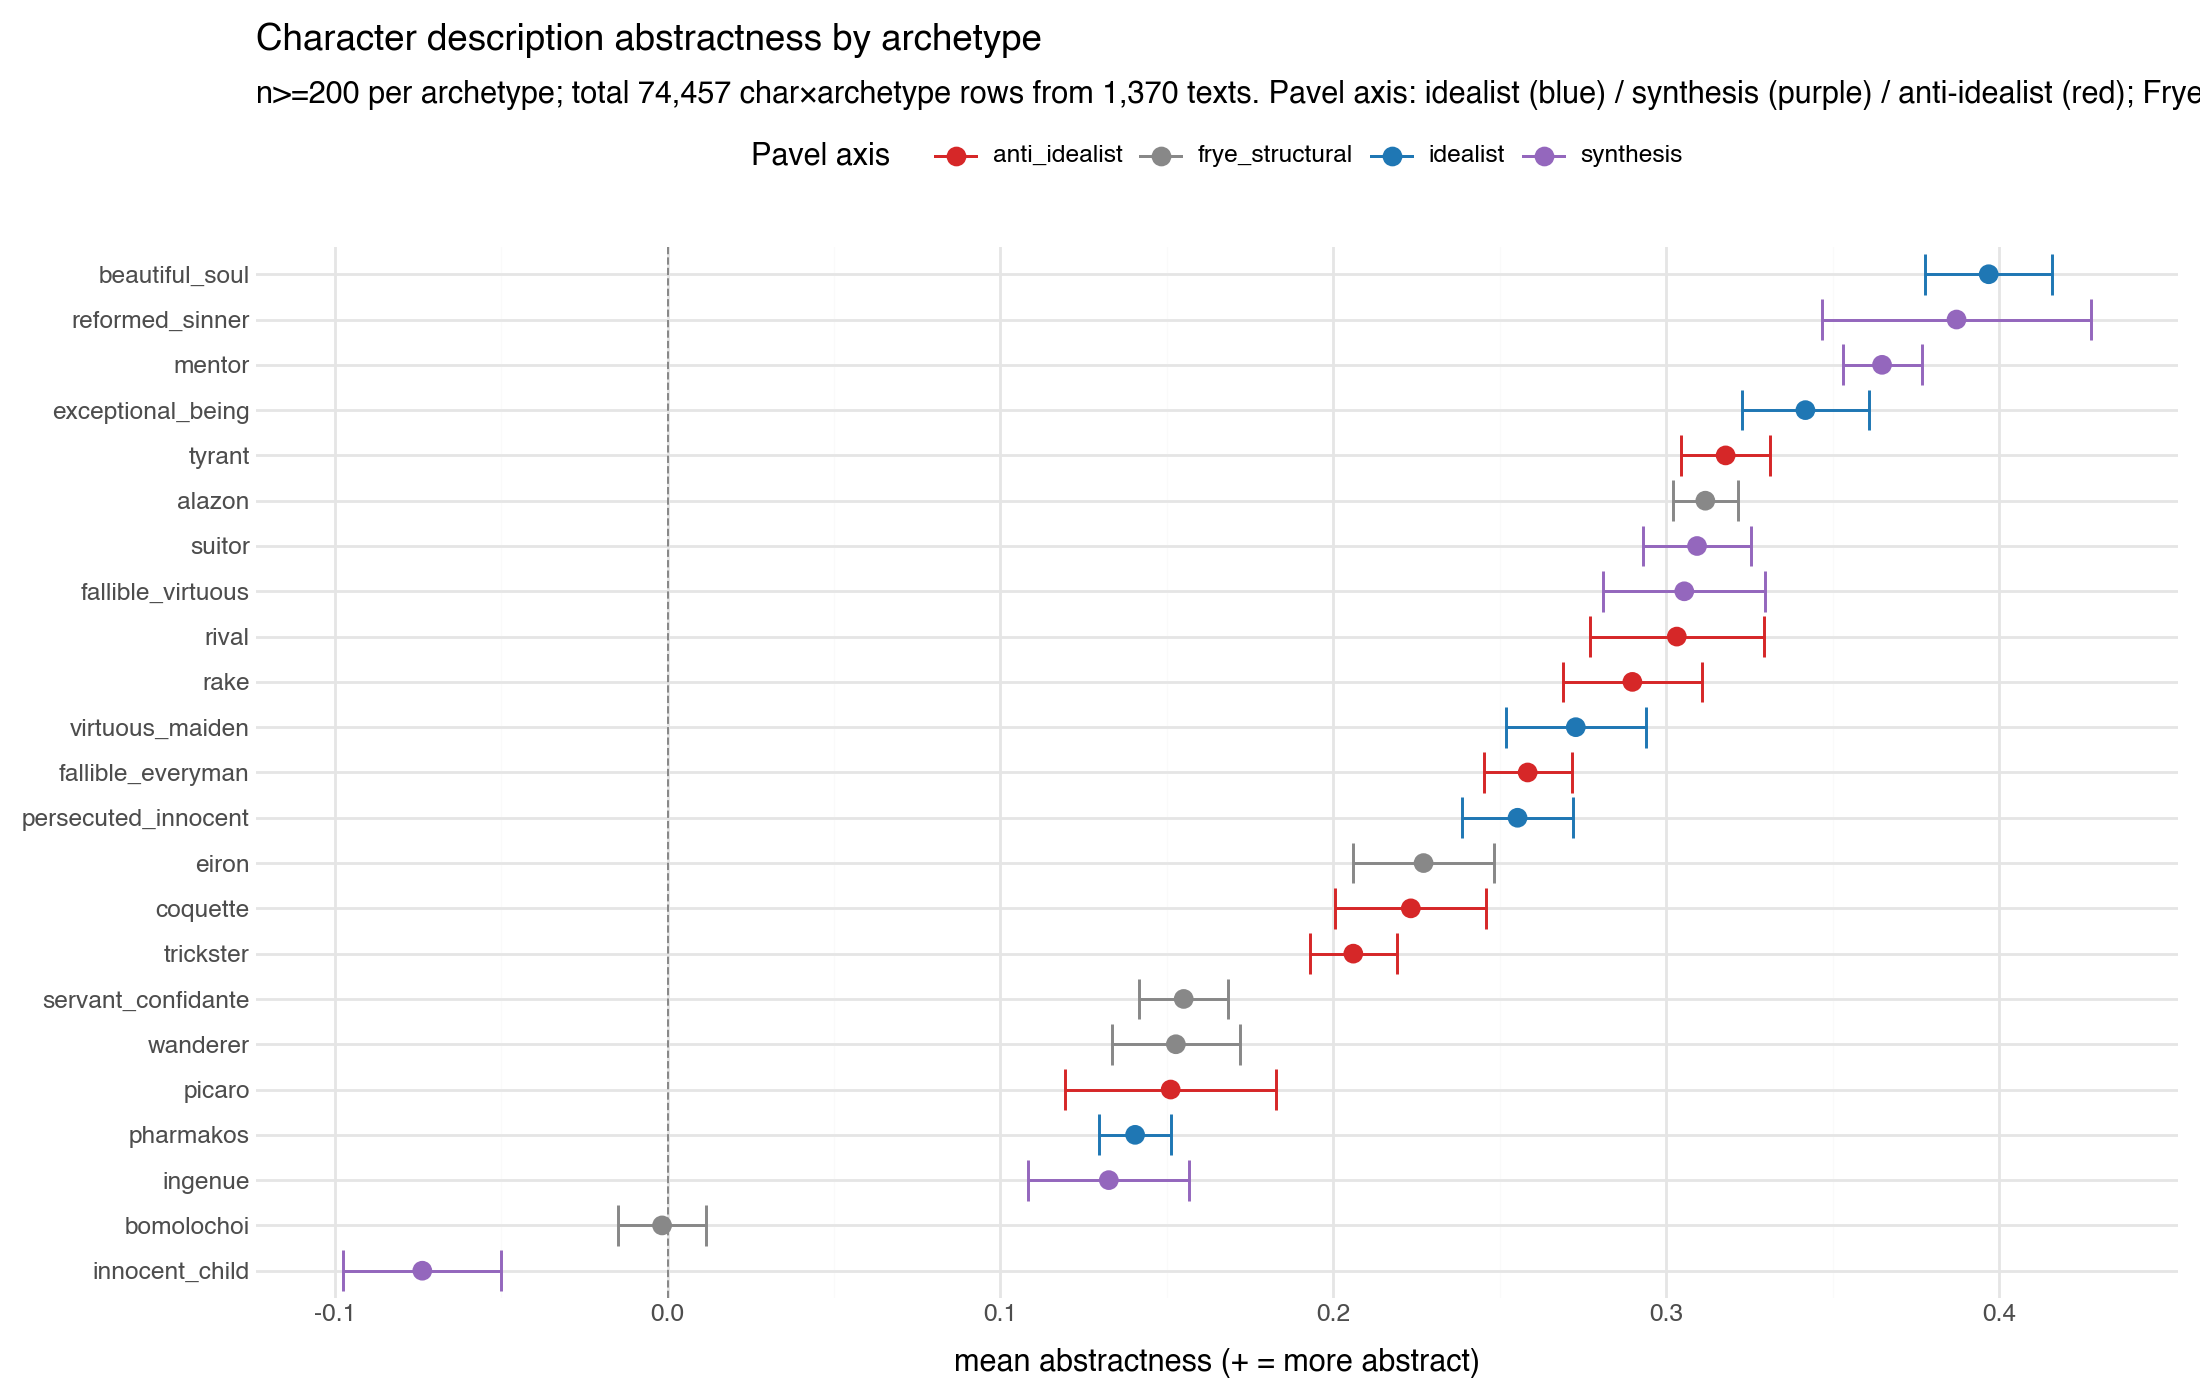

In [2]:
# Pavel-axis grouping. Tags assigned based on Pavel's tradition mapping +
# Frye structural types where applicable.
PAVEL_AXIS = {
    'idealist':     ['beautiful_soul', 'exceptional_being', 'persecuted_innocent',
                     'pharmakos', 'virtuous_maiden'],
    'synthesis':    ['fallible_virtuous', 'innocent_child', 'reformed_sinner',
                     'mentor', 'ingenue', 'suitor'],
    'anti_idealist': ['picaro', 'fallible_everyman', 'rake', 'trickster',
                      'coquette', 'rival', 'tyrant'],
    'frye_structural': ['alazon', 'eiron', 'bomolochoi', 'wanderer',
                        'servant_confidante'],
}
axis_lookup = {a: k for k, arr in PAVEL_AXIS.items() for a in arr}

# Explode
rows = []
for _, r in ch.iterrows():
    if not r['archetypes']:
        continue
    for a in r['archetypes']:
        rows.append({'source': r['source'], 'name': r['name'],
                     'archetype': a, 'pavel_axis': axis_lookup.get(a, 'other'),
                     'char_abs': r['char_abs'], 'year': r['year'],
                     'century': r['century']})
expl = pd.DataFrame(rows)
print(f'Exploded char×archetype rows: {len(expl):,}')

# Mean abs per archetype, with axis label
arch_stats = (expl.groupby('archetype').agg(
    n=('char_abs', 'count'),
    mean_abs=('char_abs', 'mean'),
    se=('char_abs', 'sem'),
    pavel_axis=('pavel_axis', 'first'),
).reset_index())
arch_stats = arch_stats[arch_stats['n'] >= 200].copy()
arch_stats['lo'] = arch_stats['mean_abs'] - 1.96 * arch_stats['se']
arch_stats['hi'] = arch_stats['mean_abs'] + 1.96 * arch_stats['se']
arch_stats = arch_stats.sort_values('mean_abs', ascending=False)
print('\nArchetype mean abstractness (n>=200, sorted by abs):')
print(arch_stats[['archetype', 'pavel_axis', 'n', 'mean_abs', 'se']]
      .to_string(index=False, float_format='%.3f'))

# Axis-level summary
axis_stats = expl[expl['pavel_axis'] != 'other'].groupby('pavel_axis').agg(
    n=('char_abs', 'count'),
    mean_abs=('char_abs', 'mean'),
    se=('char_abs', 'sem'),
).reset_index().sort_values('mean_abs', ascending=False)
print('\nAxis-level summary:')
print(axis_stats.to_string(index=False, float_format='%.3f'))

AXIS_COLORS = {
    'idealist': '#1f77b4',
    'synthesis': '#9467bd',
    'anti_idealist': '#d62728',
    'frye_structural': '#888888',
    'other': '#cccccc',
}
arch_stats['archetype'] = pd.Categorical(arch_stats['archetype'],
                                          categories=arch_stats.sort_values('mean_abs')['archetype'].tolist(),
                                          ordered=True)

p_p1 = (p9.ggplot(arch_stats, p9.aes(x='mean_abs', y='archetype', color='pavel_axis'))
        + p9.geom_vline(xintercept=0, color='#888888', linetype='dashed', size=0.4)
        + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.6)
        + p9.geom_point(size=3.0)
        + p9.scale_color_manual(values=AXIS_COLORS)
        + p9.labs(
            title='Character description abstractness by archetype',
            subtitle=f'n>=200 per archetype; total {len(expl):,} char×archetype rows from {ch["source"].nunique():,} texts. '
                     f'Pavel axis: idealist (blue) / synthesis (purple) / anti-idealist (red); Frye structural in grey.',
            x='mean abstractness (+ = more abstract)', y='', color='Pavel axis',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(11, 7), legend_position='top'))
out = os.path.join(DROPBOX_FIGS, 'character_types_archetype_abstractness.png')
p_p1.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_p1

## P2. Social class composition C16 → C20 with titled vs gentry split

qwen's class tags collapsed all aristocracy into one bucket (95% generic 'aristocrat'/'noble'); Sonnet's separates royalty / titled_nobility / untitled_gentry. Now we can ask:
1. **Composition over time**: does titled_nobility share rise into C19 (Trollope's Barchester), or stay flat?
2. **Class-abstractness gradient**: does the 'abstract description as class privilege' finding (from char-intros) hold up with cleaner tags?
3. **Gentry vs nobility**: nb15 couldn't distinguish — does the literary record privilege one over the other diachronically?

Characters per century:
century
1400      653
1500     6107
1600    17808
1700    13372
1800    12928
1900    20298
2000      598

Top classes: ['untitled_gentry', 'professional', 'titled_nobility', 'servant', 'royalty', 'merchant', 'clergy', 'laborer', 'artisan', 'criminal']


/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_class_composition_C15_C20.png

% of century's characters by class:
century           C15   C16   C17   C18   C19   C20   C21
social_class                                             
untitled_gentry  19.8  18.4  17.6  26.4  21.7  10.6   6.2
professional      3.8   7.9   8.6  12.8  14.9  22.7  47.8
titled_nobility  10.0  11.0  14.8  13.6  12.8   1.9   0.0
servant           2.0   4.5   6.8   8.8  10.1   4.5   6.5
royalty          23.3  18.3  11.8   3.8   1.5   0.7   0.2
merchant          1.1   2.5   3.9   5.6   6.3   6.2   6.0
clergy            8.9   4.3   5.8   4.9   5.9   2.7   2.8
laborer           1.1   1.6   1.5   1.7   6.1   8.7   4.2
artisan           0.6   2.8   3.2   3.1   5.8   4.9   3.8
criminal          0.3   2.5   2.7   2.5   1.6   3.3   4.3


Class abstractness gradient (overall):
                     n  mean_abs     se
social_class                           
royalty           4200     0.443  

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.


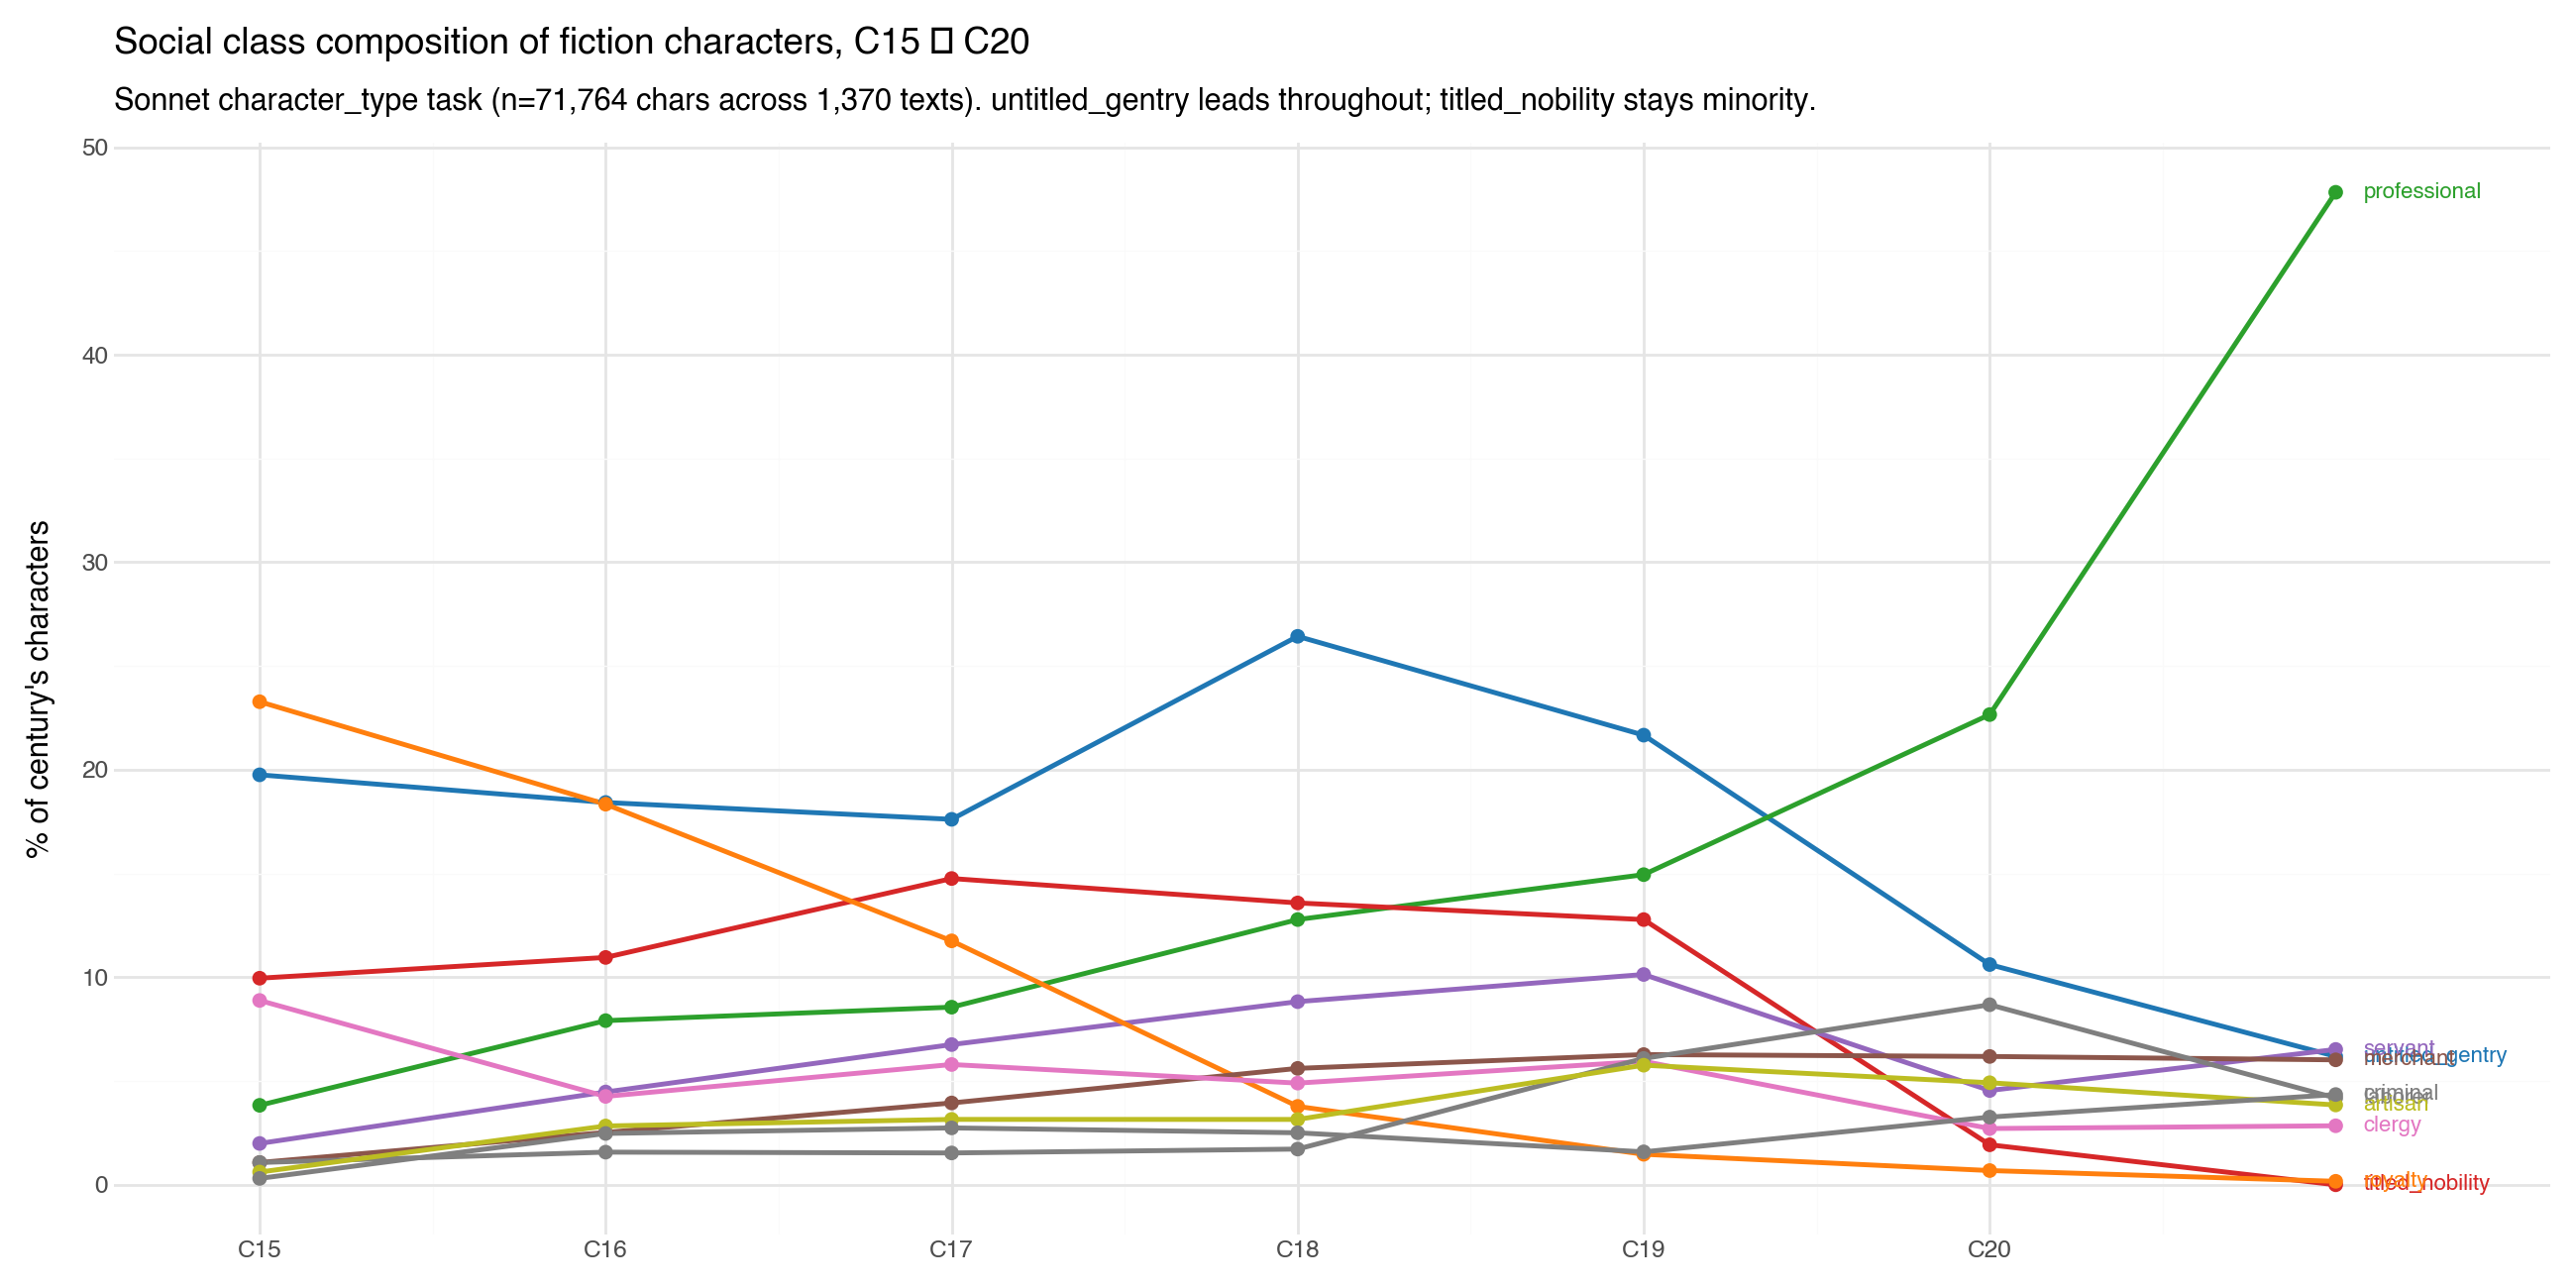

In [3]:
# Class composition by century. Single-label (each char has one class).
# Treat unknown/missing as 'unknown'; we plot only the substantively-tagged classes.
ch['social_class'] = ch['social_class'].fillna('unknown')

# Total characters per century (denominator)
tot_by_cent = ch.groupby('century').size()
print('Characters per century:')
print(tot_by_cent.to_string())

# Top classes
top_classes = (ch['social_class'].value_counts()
               .drop('unknown', errors='ignore').head(10).index.tolist())
print(f'\nTop classes: {top_classes}')

# Composition: % of each century's characters in each class
comp_rows = []
for cent, n_cent in tot_by_cent.items():
    if n_cent < 100:
        continue
    for cls in top_classes:
        n = ((ch['century'] == cent) & (ch['social_class'] == cls)).sum()
        comp_rows.append({
            'century_year': cent + 50, 'century': f'C{cent//100+1}',
            'social_class': cls, 'n': n, 'pct': n / n_cent * 100,
        })
comp = pd.DataFrame(comp_rows)

# Order classes by overall abundance
comp['social_class'] = pd.Categorical(comp['social_class'], categories=top_classes, ordered=True)

# Highlight titled_nobility vs untitled_gentry
PALETTE = {
    'untitled_gentry':  '#1f77b4',
    'titled_nobility':  '#d62728',
    'professional':     '#2ca02c',
    'royalty':          '#ff7f0e',
    'servant':          '#9467bd',
    'merchant':         '#8c564b',
    'clergy':           '#e377c2',
    'laborer':          '#7f7f7f',
    'artisan':          '#bcbd22',
    'soldier':          '#17becf',
}

labels = comp.sort_values('century_year').groupby('social_class', observed=True, as_index=False).last()

p_p2 = (p9.ggplot(comp, p9.aes(x='century_year', y='pct',
                                group='social_class', color='social_class'))
        + p9.geom_line(size=1.0)
        + p9.geom_point(size=2.0)
        + p9.geom_text(p9.aes(label='social_class'), data=labels,
                       nudge_x=8, ha='left', size=8, fontweight='bold',
                       show_legend=False)
        + p9.scale_x_continuous(breaks=[1450, 1550, 1650, 1750, 1850, 1950],
                                labels=['C15','C16','C17','C18','C19','C20'],
                                limits=(1440, 2080))
        + p9.scale_color_manual(values=PALETTE)
        + p9.labs(
            title='Social class composition of fiction characters, C15 → C20',
            subtitle=f'Sonnet character_type task (n={len(ch):,} chars across {ch["source"].nunique():,} texts). '
                     f'untitled_gentry leads throughout; titled_nobility stays minority.',
            x='', y='% of century\'s characters', color='',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(13, 6.5), legend_position='none'))
out = os.path.join(DROPBOX_FIGS, 'character_types_class_composition_C15_C20.png')
p_p2.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')

# Print the table
tbl = comp.pivot(index='social_class', columns='century', values='pct').round(1)
tbl = tbl.loc[top_classes]
print('\n% of century\'s characters by class:')
print(tbl.to_string())

# Class abstractness gradient (overall)
print('\n\nClass abstractness gradient (overall):')
cls_abs = (ch[ch['social_class'].isin(top_classes)].groupby('social_class')
           .agg(n=('char_abs','count'), mean_abs=('char_abs','mean'), se=('char_abs','sem'))
           .sort_values('mean_abs', ascending=False))
print(cls_abs.round(3).to_string())

p_p2

## P3. Within-archetype concretization across centuries

Notebook 17 found that the C18→C19→C20 fiction concretization is ~100% within-subgenre, not compositional. Character-level analog: for archetypes that span centuries (alazon, pharmakos, mentor, beautiful_soul, etc.), does the **same archetype** become more concretely described over time, or does the archetype distribution itself shift toward more concrete archetypes?

Two outputs:
1. Per-archetype × century mean abstractness — visualize trajectories.
2. Oaxaca-Blinder decomposition for C18→C19 and C19→C20 (composition vs within-archetype).

Archetypes with n>=30 in 3+ centuries: 23


/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 21 values. 23 were requested from it.


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_archetype_century_trajectory.png

Mean abstractness by archetype × century:
century                C16    C17    C18    C19    C20
archetype                                             
fallible_virtuous    0.516  0.521  0.556  0.226 -0.027
mentor               0.513  0.537  0.557  0.296  0.004
beautiful_soul       0.504  0.578  0.579  0.257 -0.057
reformed_sinner      0.492  0.561  0.497  0.243 -0.010
exceptional_being    0.432  0.446  0.494  0.247 -0.036
tyrant               0.381  0.485  0.537  0.256 -0.037
rival                0.372  0.460  0.501  0.208 -0.057
fallible_everyman    0.369  0.406  0.484  0.221 -0.054
coquette             0.341  0.323  0.416  0.171 -0.136
suitor               0.334  0.410  0.441  0.192 -0.050
alazon               0.333  0.458  0.507  0.267  0.033
persecuted_innocent  0.327  0.394  0.408  0.159 -0.127
virtuous_maiden      0.317  0.373  0.371  0.085 -0.181
eiron             

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 21 values. 23 were requested from it.


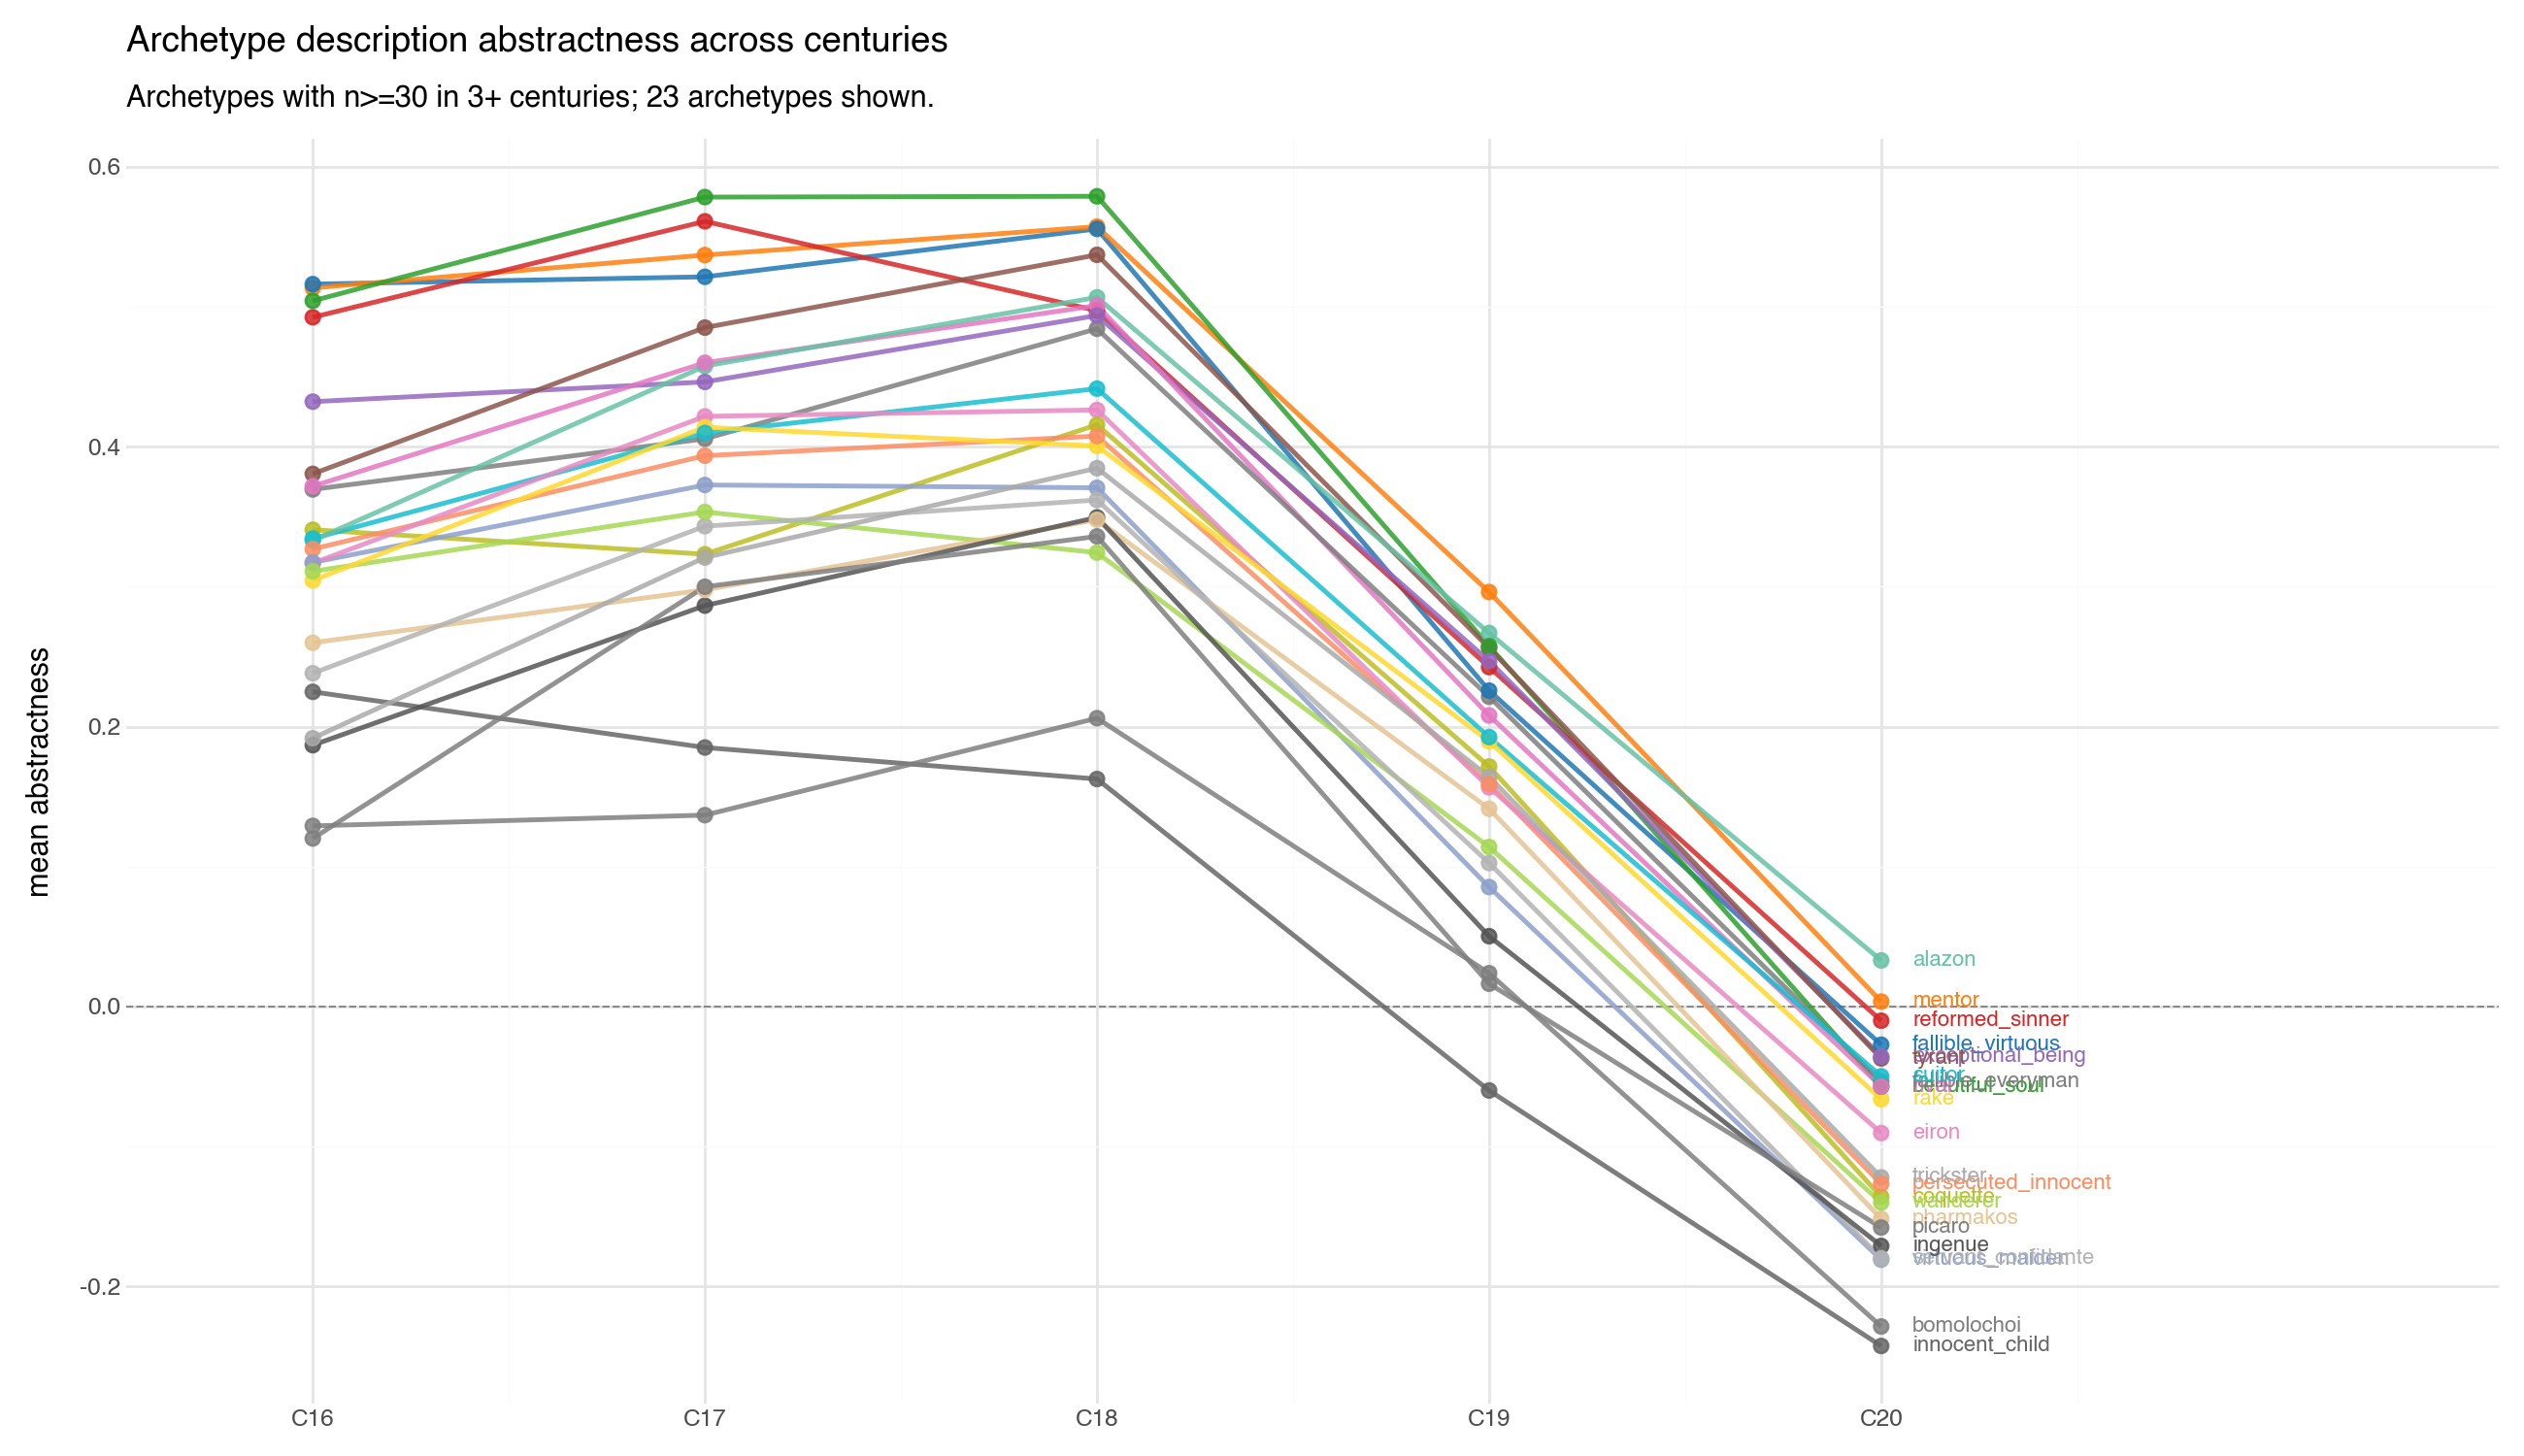

In [4]:
# Per-archetype × century mean abstractness for archetypes spanning C17→C20.
# Use the exploded char×archetype DataFrame from P1.
rows = []
for arch in expl['archetype'].unique():
    for cent in (1500, 1600, 1700, 1800, 1900):
        sub = expl[(expl['archetype'] == arch) & (expl['century'] == cent)]
        if len(sub) >= 30:
            rows.append({
                'archetype': arch, 'century_year': cent + 50,
                'century': f'C{cent//100+1}',
                'pavel_axis': sub['pavel_axis'].iloc[0],
                'n': len(sub),
                'mean_abs': sub['char_abs'].mean(),
                'se': sub['char_abs'].sem(),
            })
tdf = pd.DataFrame(rows)
n_cents_per_arch = tdf.groupby('archetype')['century_year'].nunique()
multi = n_cents_per_arch[n_cents_per_arch >= 3].index.tolist()
tdf = tdf[tdf['archetype'].isin(multi)].copy()
print(f'Archetypes with n>=30 in 3+ centuries: {len(multi)}')

# Trajectory plot
tab10_h = [mcolors.to_hex(c) for c in mcm.tab10.colors]
set2_h = [mcolors.to_hex(c) for c in mcm.Set2.colors]
anchor = tdf.groupby('archetype')['mean_abs'].first().reindex(multi)
arch_order = anchor.sort_values(ascending=False).index.tolist()
palette = dict(zip(arch_order, (tab10_h + set2_h + ['#666666', '#aaaaaa', '#555555'])[:len(arch_order)]))
tdf['archetype'] = pd.Categorical(tdf['archetype'], categories=arch_order, ordered=True)
labels = tdf.sort_values('century_year').groupby('archetype', observed=True, as_index=False).last()

p_p3 = (p9.ggplot(tdf, p9.aes(x='century_year', y='mean_abs',
                              group='archetype', color='archetype'))
        + p9.geom_hline(yintercept=0, color='#888888', size=0.4, linetype='dashed')
        + p9.geom_line(size=1.0, alpha=0.85)
        + p9.geom_point(size=2.5, alpha=0.85)
        + p9.geom_text(p9.aes(label='archetype'), data=labels,
                       nudge_x=8, ha='left', size=8, fontweight='bold',
                       show_legend=False)
        + p9.scale_color_manual(values=palette)
        + p9.scale_x_continuous(breaks=[1550, 1650, 1750, 1850, 1950],
                                labels=['C16','C17','C18','C19','C20'],
                                limits=(1530, 2080))
        + p9.labs(
            title='Archetype description abstractness across centuries',
            subtitle=f'Archetypes with n>=30 in 3+ centuries; {len(multi)} archetypes shown.',
            x='', y='mean abstractness', color='',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(13, 7.5), legend_position='none'))
out = os.path.join(DROPBOX_FIGS, 'character_types_archetype_century_trajectory.png')
p_p3.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

# Print transitions table for spanning archetypes
tbl = tdf.pivot(index='archetype', columns='century', values='mean_abs').round(3)
tbl = tbl.reindex(arch_order)
print('\nMean abstractness by archetype × century:')
print(tbl.to_string())

# Oaxaca-Blinder for C18→C19 and C19→C20 using primary archetype
ctr_arch = expl['archetype'].value_counts().to_dict()
def primary_archetype(tags):
    if not tags: return 'none'
    return max(tags, key=lambda t: ctr_arch.get(t, 0))
ch_with = ch[ch['archetypes'].apply(bool)].copy()
ch_with['parch'] = ch_with['archetypes'].apply(primary_archetype)

def oaxaca_arch(c0, c1):
    sub = ch_with[ch_with['century'].isin([c0, c1])].copy()
    sub['__period'] = sub['century'].map({c0:'C0', c1:'C1'})
    pc = sub.groupby(['__period','parch']).size().unstack(fill_value=0)
    if 'C0' not in pc.index or 'C1' not in pc.index:
        return None
    viable = pc.columns[(pc.loc['C0'] >= 30) & (pc.loc['C1'] >= 30)].tolist()
    sub2 = sub[sub['parch'].isin(viable)]
    grp = sub2.groupby(['__period','parch'])['char_abs'].agg(['mean','size']).reset_index()
    p0 = grp[grp['__period']=='C0'].set_index('parch')
    p1 = grp[grp['__period']=='C1'].set_index('parch')
    common = sorted(set(p0.index) & set(p1.index))
    n0 = p0.loc[common,'size'].sum(); n1 = p1.loc[common,'size'].sum()
    w0 = p0.loc[common,'size']/n0; w1 = p1.loc[common,'size']/n1
    mu0 = p0.loc[common,'mean']; mu1 = p1.loc[common,'mean']
    return {
        'comp': ((w1-w0)*mu0).sum(),
        'within': (w0*(mu1-mu0)).sum(),
        'inter': ((w1-w0)*(mu1-mu0)).sum(),
        'total': (w1*mu1).sum() - (w0*mu0).sum(),
        'k': len(common), 'n0': int(n0), 'n1': int(n1),
    }

print('\n--- Oaxaca-Blinder decomposition (primary archetype) ---')
for c0, c1, label in [(1600, 1700, 'C17→C18'), (1700, 1800, 'C18→C19'), (1800, 1900, 'C19→C20')]:
    r = oaxaca_arch(c0, c1)
    if r is None: continue
    print(f'{label} (k={r["k"]}, n={r["n0"]}+{r["n1"]}): total={r["total"]:+.4f}  '
          f'comp={r["comp"]:+.4f}  within={r["within"]:+.4f}  inter={r["inter"]:+.4f}')
    pct_comp = r['comp']/r['total']*100 if r['total'] else 0
    pct_within = r['within']/r['total']*100 if r['total'] else 0
    print(f'    composition: {pct_comp:+.1f}%   within: {pct_within:+.1f}%')

p_p3

## P4. Archetype × plot_genre cross-tabulation

Sanity check + supporting evidence: do LLM-extracted archetypes line up with Pavel's tradition labels at the plot_genre layer? Specifically:
1. Idealist tradition texts → over-represented in pharmakos, persecuted_innocent, beautiful_soul archetypes?
2. Anti-idealist tradition texts → over-represented in picaro, fallible_everyman, trickster?

Lift heatmap on the joint sample (texts with both plot_genre and character_type tags).

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


plot_genre annotations: 1,452
Characters with plot_genre + character_type: 71,764 across 1,370 texts


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_archetype_pavel_lift.png

Strongest associations (lift > 1.3 or < 0.75, n>=10):
        archetype pavel_tradition  lift  n_joint
exceptional_being        idealist  1.55     1212
            eiron        idealist  0.71      522
       bomolochoi        idealist  0.55     1052
   innocent_child       synthesis  1.34      492
exceptional_being       synthesis  0.44      218
   beautiful_soul   anti_idealist  0.71      686


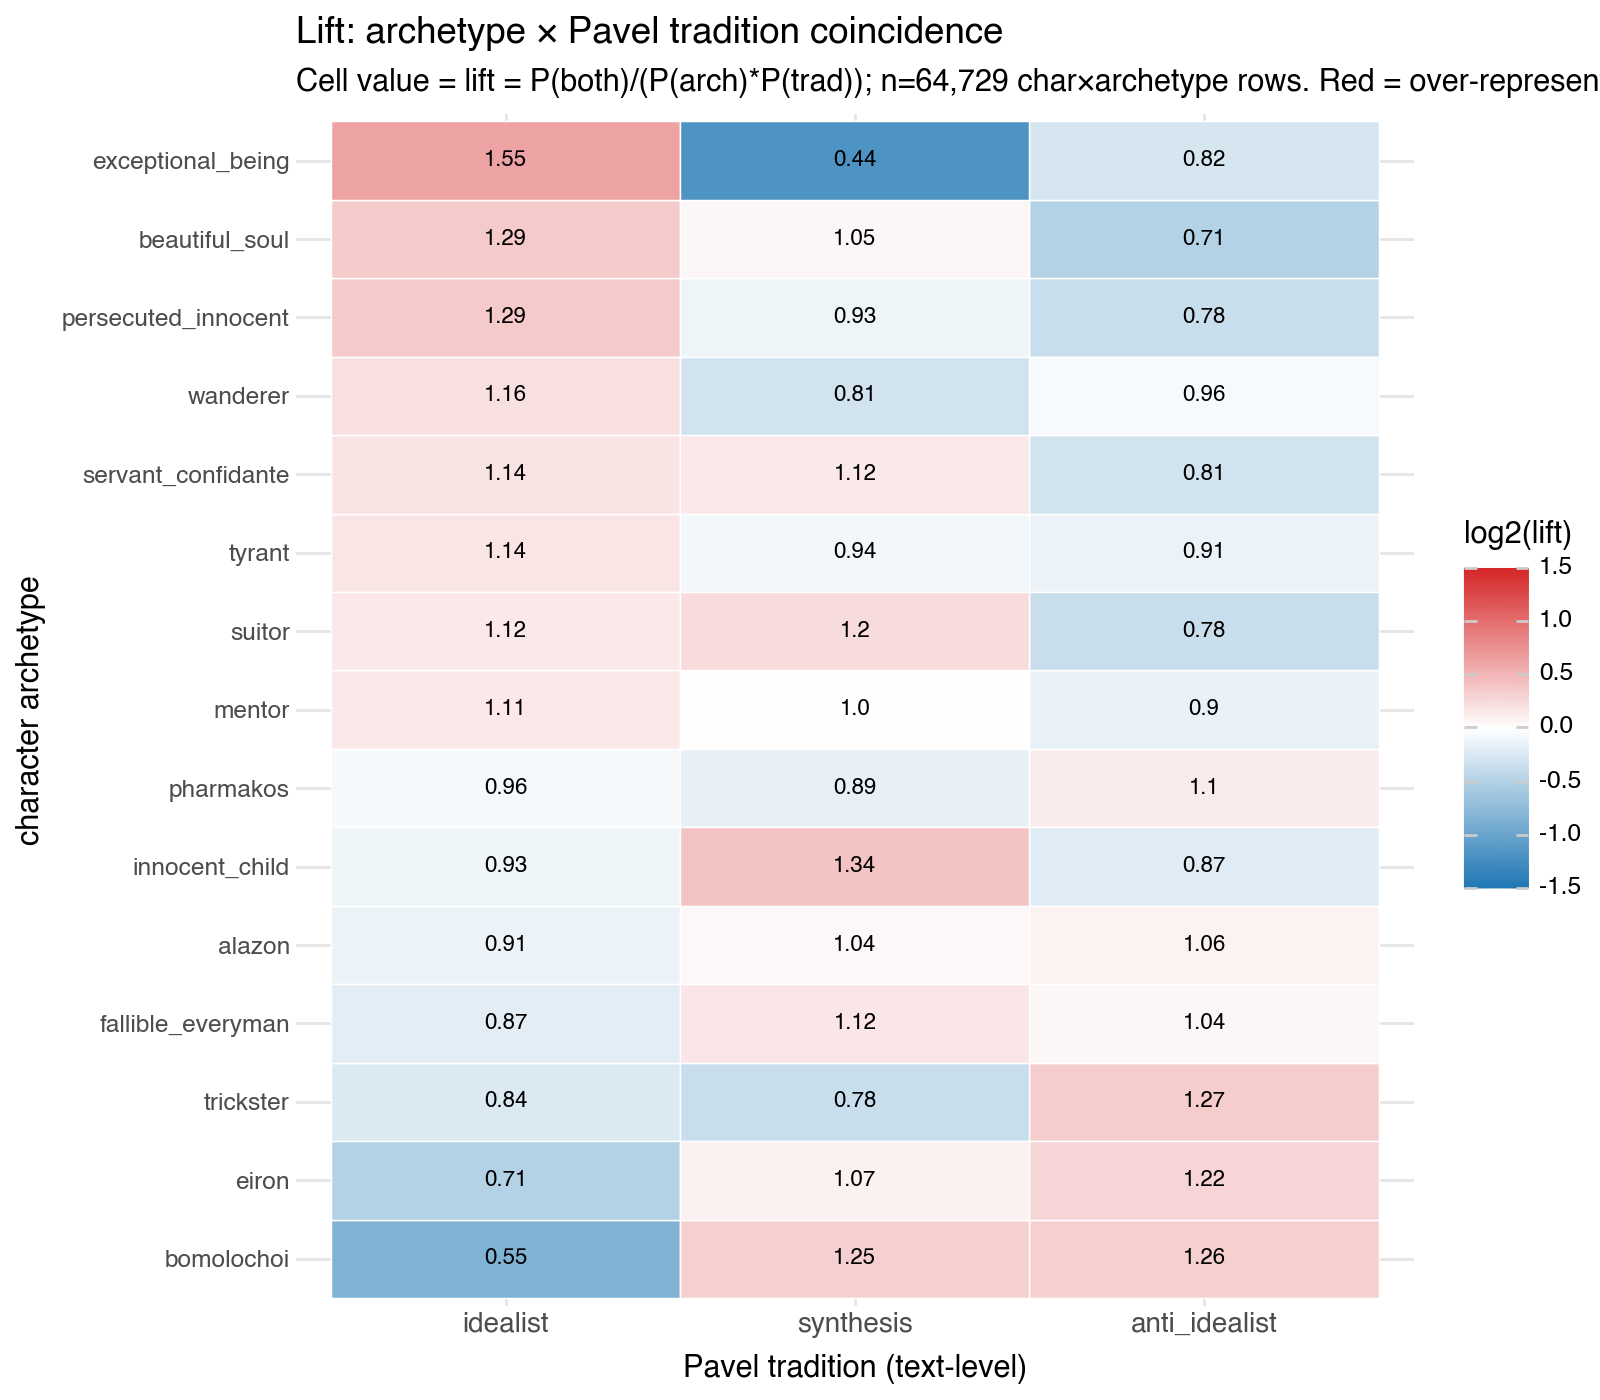

In [5]:
from lltk.annotate import iter_task_results

# Pull plot_genre annotations
pg_rows = []
for _id, d in iter_task_results('plot_genre'):
    pg_rows.append({
        'source': _id,
        'pavel_tradition': d.get('pavel_tradition'),
        'mythos': d.get('mythos'),
        'frye_mode': d.get('frye_mode'),
    })
pg_df = pd.DataFrame(pg_rows)
print(f'plot_genre annotations: {len(pg_df):,}')

# Join with characters
ch_pg = ch.merge(pg_df, on='source', how='inner')
print(f'Characters with plot_genre + character_type: {len(ch_pg):,} across {ch_pg["source"].nunique():,} texts')

# Explode archetypes
exp_pg = []
for _, r in ch_pg.iterrows():
    for a in r['archetypes']:
        exp_pg.append({'source': r['source'], 'archetype': a,
                       'pavel_tradition': r['pavel_tradition'],
                       'mythos': r['mythos'], 'frye_mode': r['frye_mode']})
exp_pg = pd.DataFrame(exp_pg)
exp_pg = exp_pg[exp_pg['pavel_tradition'].notna()]

# Top archetypes
top_arch = exp_pg['archetype'].value_counts().head(15).index.tolist()
exp_pg = exp_pg[exp_pg['archetype'].isin(top_arch)]

# Lift table: archetype × pavel_tradition
N = len(exp_pg)
lift_rows = []
for trad in exp_pg['pavel_tradition'].unique():
    p_trad = (exp_pg['pavel_tradition'] == trad).mean()
    for arch in top_arch:
        in_arch = exp_pg['archetype'] == arch
        p_arch = in_arch.mean()
        in_trad = exp_pg['pavel_tradition'] == trad
        n_joint = (in_arch & in_trad).sum()
        if n_joint < 5:
            continue
        p_joint = n_joint / N
        lift = p_joint / (p_arch * p_trad)
        lift_rows.append({
            'archetype': arch, 'pavel_tradition': trad,
            'lift': lift, 'log2_lift': np.log2(lift) if lift > 0 else np.nan,
            'n_joint': int(n_joint),
        })
lift_df = pd.DataFrame(lift_rows)

# Order archetypes by mean log2_lift toward idealist
ideal_lift = (lift_df[lift_df['pavel_tradition'] == 'idealist']
              .set_index('archetype')['log2_lift'])
arch_ord = ideal_lift.sort_values(ascending=False).index.tolist()
trad_ord = ['idealist', 'synthesis', 'anti_idealist']
lift_df['archetype'] = pd.Categorical(lift_df['archetype'], categories=arch_ord[::-1], ordered=True)
lift_df['pavel_tradition'] = pd.Categorical(lift_df['pavel_tradition'],
                                              categories=trad_ord, ordered=True)

p_p4 = (p9.ggplot(lift_df, p9.aes(x='pavel_tradition', y='archetype', fill='log2_lift'))
        + p9.geom_tile(color='white', size=0.3)
        + p9.geom_text(p9.aes(label='lift'),
                       data=lift_df.assign(lift=lift_df['lift'].round(2)),
                       size=8)
        + p9.scale_fill_gradient2(low='#1f77b4', mid='white', high='#d62728',
                                  midpoint=0, limits=(-1.5, 1.5))
        + p9.labs(
            title='Lift: archetype × Pavel tradition coincidence',
            subtitle=f'Cell value = lift = P(both)/(P(arch)*P(trad)); n={N:,} char×archetype rows. '
                     f'Red = over-represented; blue = under-represented.',
            x='Pavel tradition (text-level)', y='character archetype',
            fill='log2(lift)',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(8, 7), axis_text_x=p9.element_text(size=10)))
out = os.path.join(DROPBOX_FIGS, 'character_types_archetype_pavel_lift.png')
p_p4.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

# Print strongest associations
print('\nStrongest associations (lift > 1.3 or < 0.75, n>=10):')
strong = lift_df[((lift_df['lift'] > 1.3) | (lift_df['lift'] < 0.75)) & (lift_df['n_joint'] >= 10)]
print(strong.sort_values(['pavel_tradition', 'lift'], ascending=[True, False])[
    ['archetype', 'pavel_tradition', 'lift', 'n_joint']
].to_string(index=False, float_format='%.2f'))

p_p4

## P5. Within-class concretization across centuries

Complement to P3. P2 showed compositional shift (royalty falls, professional rises) and a steady class abstractness gradient. P5 asks: within each *class*, do C19/C20 royals/gentry/etc. get described as abstractly as their C17/C18 counterparts?

If within-class concretization is real and large, the C19-C20 abstractness fall is yet again driven primarily by *within-form* register collapse rather than compositional shift. If it's modest, then class composition matters more than the subgenre/archetype analyses suggested.

Same Oaxaca-Blinder framework as P3, with class as the grouping variable.

Classes with n>=30 in 3+ centuries: 10


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_class_century_trajectory.png

Mean abstractness by class × century:
century            C16    C17    C18    C19    C20
social_class                                      
clergy           0.531  0.508  0.558  0.354  0.142
professional     0.499  0.480  0.389  0.234  0.044
royalty          0.413  0.467  0.531  0.400  0.183
titled_nobility  0.361  0.464  0.463  0.307  0.126
untitled_gentry  0.313  0.357  0.441  0.214 -0.000
servant          0.099  0.159  0.191 -0.092 -0.288
criminal         0.094  0.141  0.149 -0.025 -0.330
laborer          0.047 -0.020  0.047 -0.145 -0.341
merchant         0.016  0.134  0.251  0.041 -0.187
artisan         -0.075 -0.042  0.062 -0.150 -0.325

--- Oaxaca-Blinder decomposition (social class) ---
C17→C18 (k=10, n=13640+11135): total=+0.0181  comp=-0.0172  within=+0.0374  inter=-0.0022
    composition: -95.2%   within: +207.1%
C18→C19 (k=10, n=11135+11202): total=-0.2351  comp=-0.

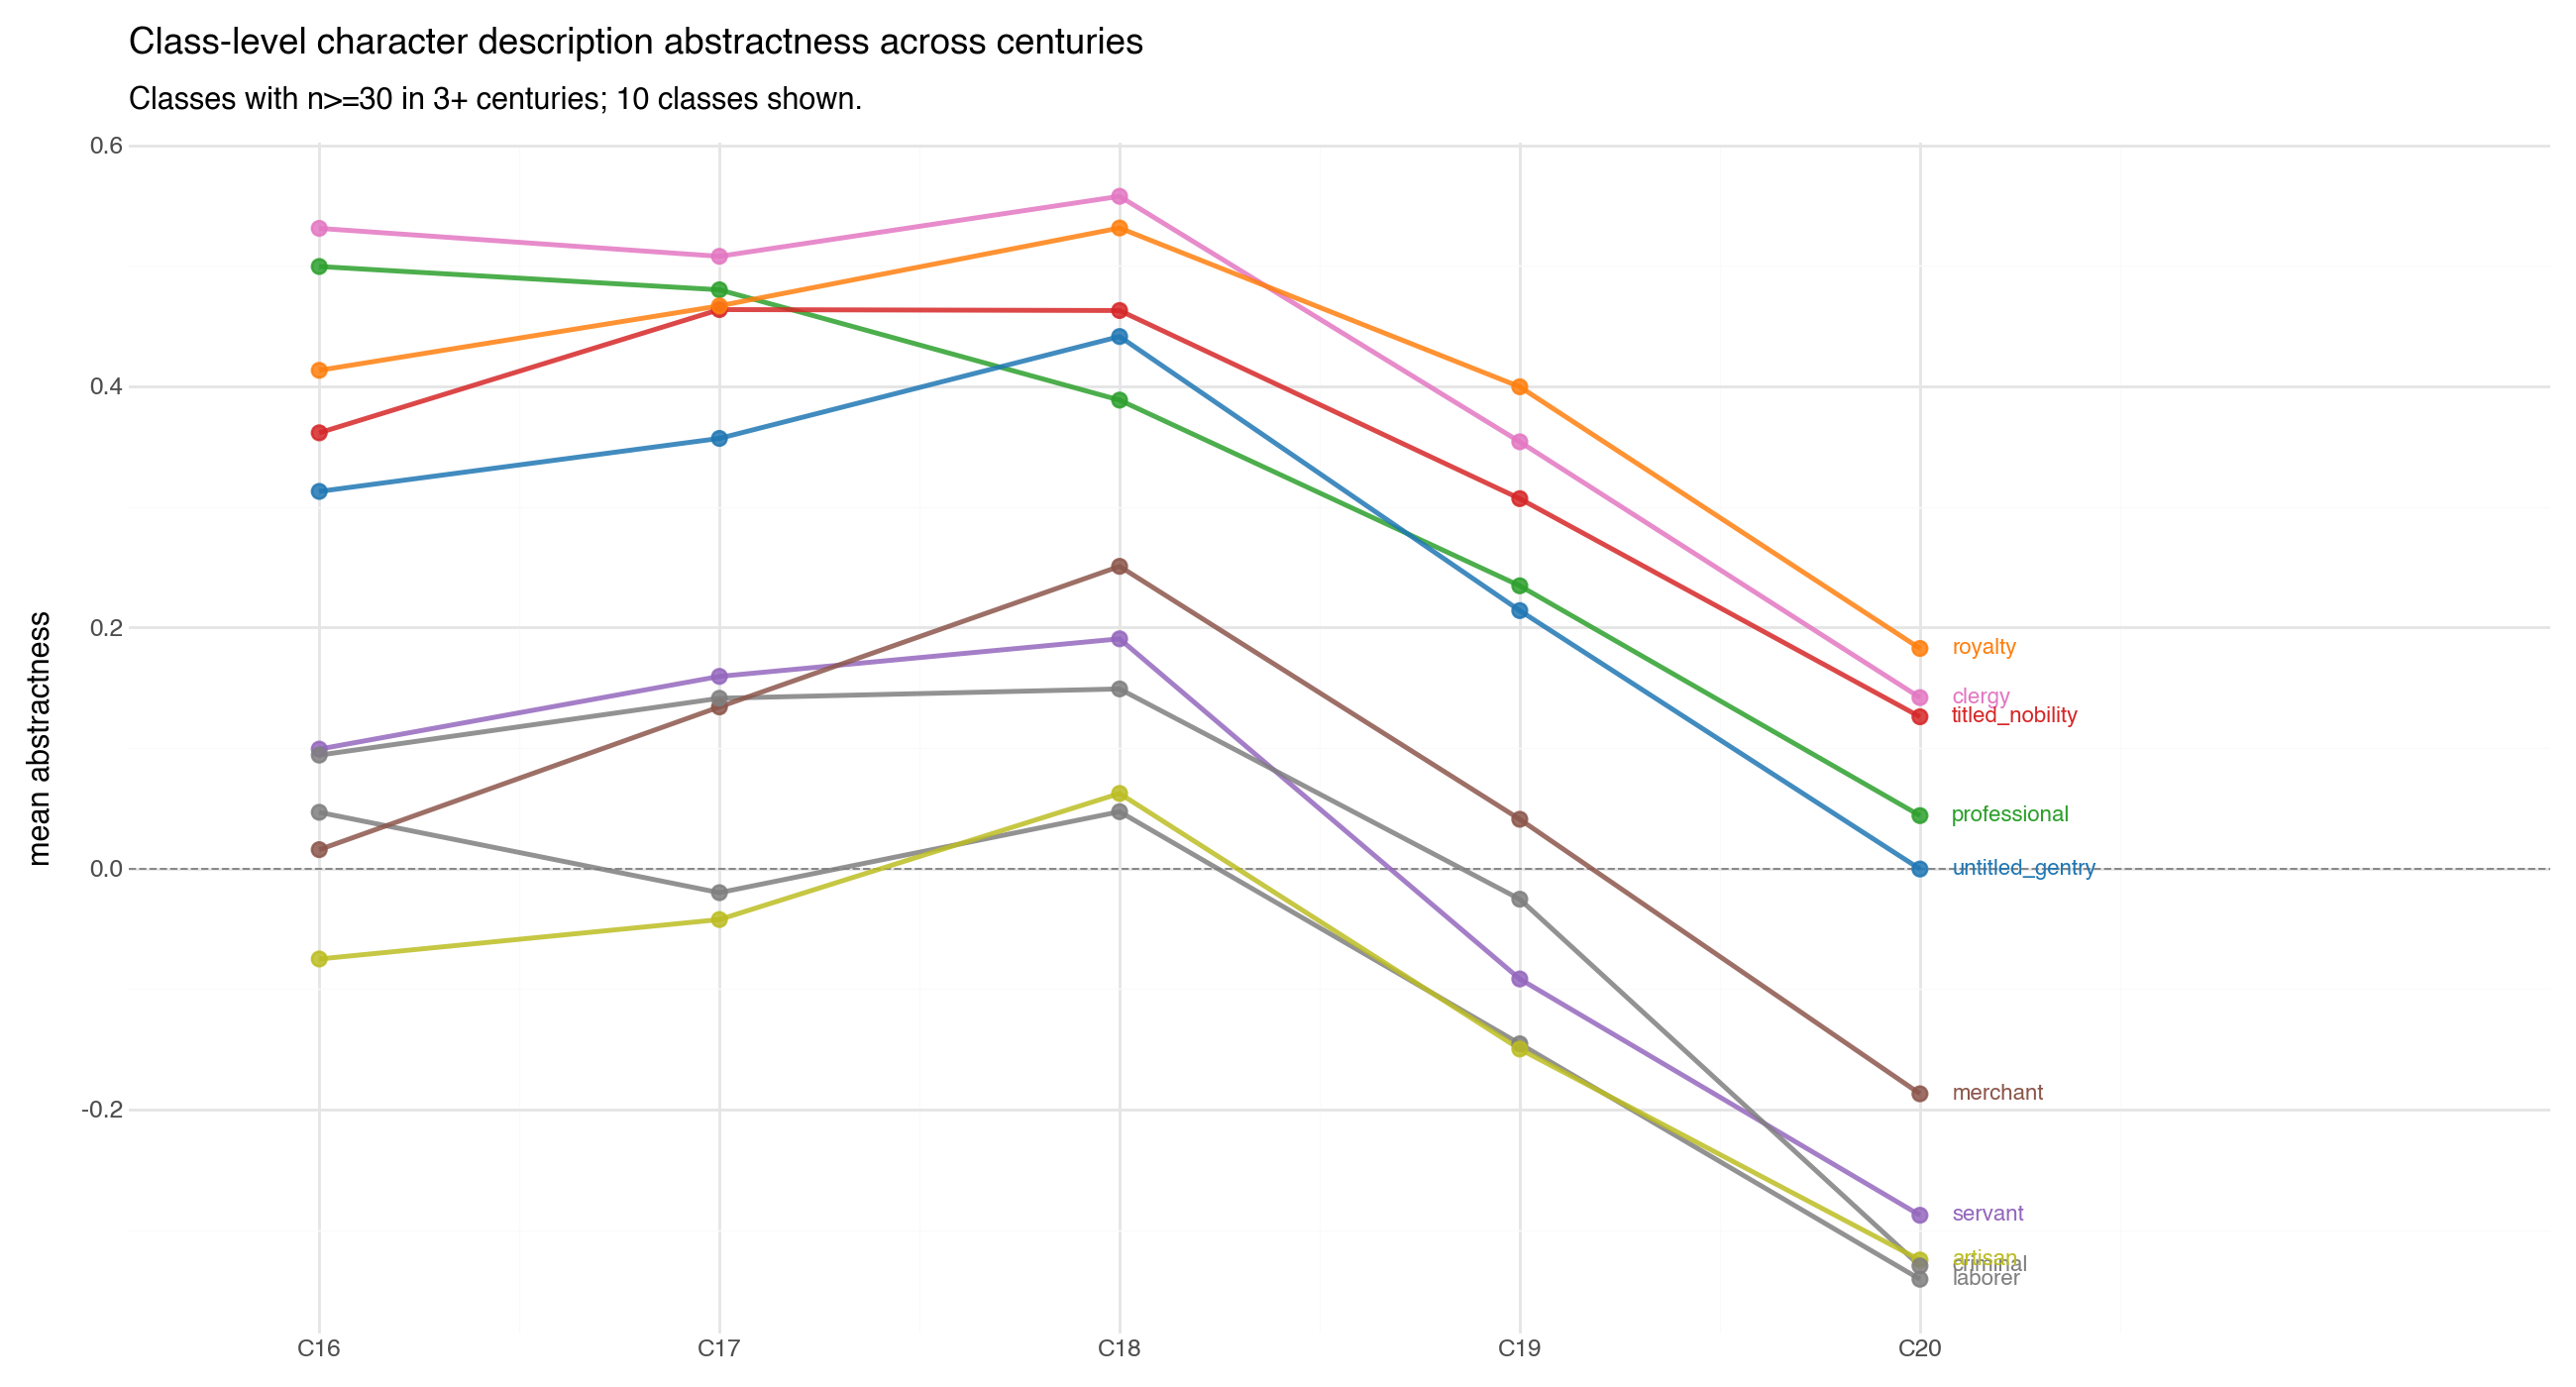

In [6]:
# Per-class × century mean abstractness for classes spanning C16→C20.
rows = []
for cls in top_classes:
    for cent in (1500, 1600, 1700, 1800, 1900):
        sub = ch[(ch['social_class'] == cls) & (ch['century'] == cent)]
        if len(sub) >= 30:
            rows.append({
                'social_class': cls, 'century_year': cent + 50,
                'century': f'C{cent//100+1}',
                'n': len(sub),
                'mean_abs': sub['char_abs'].mean(),
                'se': sub['char_abs'].sem(),
            })
tdf = pd.DataFrame(rows)
n_cents_per_cls = tdf.groupby('social_class')['century_year'].nunique()
multi = n_cents_per_cls[n_cents_per_cls >= 3].index.tolist()
tdf = tdf[tdf['social_class'].isin(multi)].copy()
print(f'Classes with n>=30 in 3+ centuries: {len(multi)}')

# Order by C18 (or earliest available) - abstract on top
anchor = tdf.groupby('social_class')['mean_abs'].first().reindex(multi)
cls_order = anchor.sort_values(ascending=False).index.tolist()
tdf['social_class'] = pd.Categorical(tdf['social_class'], categories=cls_order, ordered=True)
labels = tdf.sort_values('century_year').groupby('social_class', observed=True, as_index=False).last()

p_p5 = (p9.ggplot(tdf, p9.aes(x='century_year', y='mean_abs',
                              group='social_class', color='social_class'))
        + p9.geom_hline(yintercept=0, color='#888888', size=0.4, linetype='dashed')
        + p9.geom_line(size=1.0, alpha=0.85)
        + p9.geom_point(size=2.5, alpha=0.85)
        + p9.geom_text(p9.aes(label='social_class'), data=labels,
                       nudge_x=8, ha='left', size=8, fontweight='bold',
                       show_legend=False)
        + p9.scale_color_manual(values=PALETTE)
        + p9.scale_x_continuous(breaks=[1550, 1650, 1750, 1850, 1950],
                                labels=['C16','C17','C18','C19','C20'],
                                limits=(1530, 2080))
        + p9.labs(
            title='Class-level character description abstractness across centuries',
            subtitle=f'Classes with n>=30 in 3+ centuries; {len(multi)} classes shown.',
            x='', y='mean abstractness', color='',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(13, 7), legend_position='none'))
out = os.path.join(DROPBOX_FIGS, 'character_types_class_century_trajectory.png')
p_p5.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

# Print transitions table
tbl = tdf.pivot(index='social_class', columns='century', values='mean_abs').round(3)
tbl = tbl.reindex(cls_order)
print('\nMean abstractness by class × century:')
print(tbl.to_string())

# Oaxaca-Blinder using social_class as group
ch_cls = ch[ch['social_class'].isin(top_classes) & (ch['social_class'] != 'unknown')].copy()

def oaxaca_class(c0, c1, min_n=30):
    sub = ch_cls[ch_cls['century'].isin([c0, c1])].copy()
    sub['__period'] = sub['century'].map({c0:'C0', c1:'C1'})
    pc = sub.groupby(['__period','social_class']).size().unstack(fill_value=0)
    if 'C0' not in pc.index or 'C1' not in pc.index: return None
    viable = pc.columns[(pc.loc['C0'] >= min_n) & (pc.loc['C1'] >= min_n)].tolist()
    sub2 = sub[sub['social_class'].isin(viable)]
    grp = sub2.groupby(['__period','social_class'])['char_abs'].agg(['mean','size']).reset_index()
    p0 = grp[grp['__period']=='C0'].set_index('social_class')
    p1 = grp[grp['__period']=='C1'].set_index('social_class')
    common = sorted(set(p0.index) & set(p1.index))
    n0 = p0.loc[common,'size'].sum(); n1 = p1.loc[common,'size'].sum()
    w0 = p0.loc[common,'size']/n0; w1 = p1.loc[common,'size']/n1
    mu0 = p0.loc[common,'mean']; mu1 = p1.loc[common,'mean']
    return {
        'comp': ((w1-w0)*mu0).sum(),
        'within': (w0*(mu1-mu0)).sum(),
        'inter': ((w1-w0)*(mu1-mu0)).sum(),
        'total': (w1*mu1).sum() - (w0*mu0).sum(),
        'k': len(common), 'n0': int(n0), 'n1': int(n1),
    }

print('\n--- Oaxaca-Blinder decomposition (social class) ---')
for c0, c1, label in [(1600, 1700, 'C17→C18'), (1700, 1800, 'C18→C19'), (1800, 1900, 'C19→C20')]:
    r = oaxaca_class(c0, c1)
    if r is None: continue
    print(f'{label} (k={r["k"]}, n={r["n0"]}+{r["n1"]}): total={r["total"]:+.4f}  '
          f'comp={r["comp"]:+.4f}  within={r["within"]:+.4f}  inter={r["inter"]:+.4f}')
    pct_comp = r['comp']/r['total']*100 if r['total'] else 0
    pct_within = r['within']/r['total']*100 if r['total'] else 0
    print(f'    composition: {pct_comp:+.1f}%   within: {pct_within:+.1f}%')

p_p5

## P6. Detrended versions: deviation from period baseline

P3 and P5 showed everything concretizes C18→C20 in absolute terms. The harder question: does each archetype/class concretize *more or less than its period's overall trend*? Did the class gradient *widen* (aristocratic privilege intensifies) or *narrow* (the abstract register democratizes) relative to baseline?

Detrend: for each (group, century) cell, plot mean_abs **minus the period mean across all characters**. + means more abstract than the period baseline; − means more concrete. Visualizes the *position* of each group relative to its period.

Two views: archetype-deviation and class-deviation.

Century baseline (corpus mean per century):
century
1400    0.212
1500    0.322
1600    0.353
1700    0.368
1800    0.125
1900   -0.118
2000   -0.002



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_archetype_deviation.png

Archetype deviation from period baseline:
                       C16    C17    C18    C19    C20
archetype                                             
fallible_virtuous    0.194  0.168  0.187  0.101  0.091
mentor               0.192  0.184  0.189  0.171  0.122
beautiful_soul       0.182  0.225  0.211  0.133  0.061
reformed_sinner      0.171  0.208  0.129  0.118  0.108
exceptional_being    0.110  0.093  0.126  0.122  0.083
tyrant               0.059  0.132  0.169  0.131  0.081
rival                0.050  0.107  0.133  0.083  0.061
fallible_everyman    0.048  0.052  0.116  0.097  0.065
coquette             0.019 -0.030  0.047  0.047 -0.018
suitor               0.013  0.057  0.073  0.068  0.068
alazon               0.011  0.104  0.139  0.142  0.151
persecuted_innocent  0.005  0.040  0.039  0.034 -0.008
virtuous_maiden     -0.004  0.019  0.002 -0.039 -0.063
eiron               -0.005

Classes with n>=30 in 3+ centuries: 18 -> ['artisan', 'beggar', 'clergy', 'commoner', 'criminal', 'foreign_noble', 'laborer', 'merchant', 'professional', 'royalty', 'sailor', 'servant', 'slave', 'soldier', 'supernatural', 'titled_nobility', 'untitled_gentry', 'yeoman_farmer']



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_class_deviation.png

Class deviation from period baseline (all 3+century classes):
                   C16    C17    C18    C19    C20
social_class                                      
clergy           0.209  0.155  0.189  0.229  0.260
professional     0.178  0.127  0.020  0.110  0.162
commoner         0.143 -0.080 -0.389  0.028  0.063
royalty          0.092  0.113  0.163  0.275  0.301
titled_nobility  0.040  0.110  0.095  0.182  0.244
foreign_noble    0.004  0.046  0.069  0.073  0.167
untitled_gentry -0.009  0.004  0.073  0.089  0.118
slave              NaN -0.122 -0.165    NaN -0.105
soldier         -0.135 -0.133 -0.240 -0.116 -0.095
yeoman_farmer   -0.151 -0.225 -0.198 -0.151 -0.121
beggar             NaN -0.154 -0.388 -0.161 -0.303
supernatural    -0.188 -0.042    NaN    NaN -0.140
servant         -0.223 -0.194 -0.178 -0.216 -0.169
criminal        -0.228 -0.212 -0.219 -0.150 -0.211
laborer         -0.

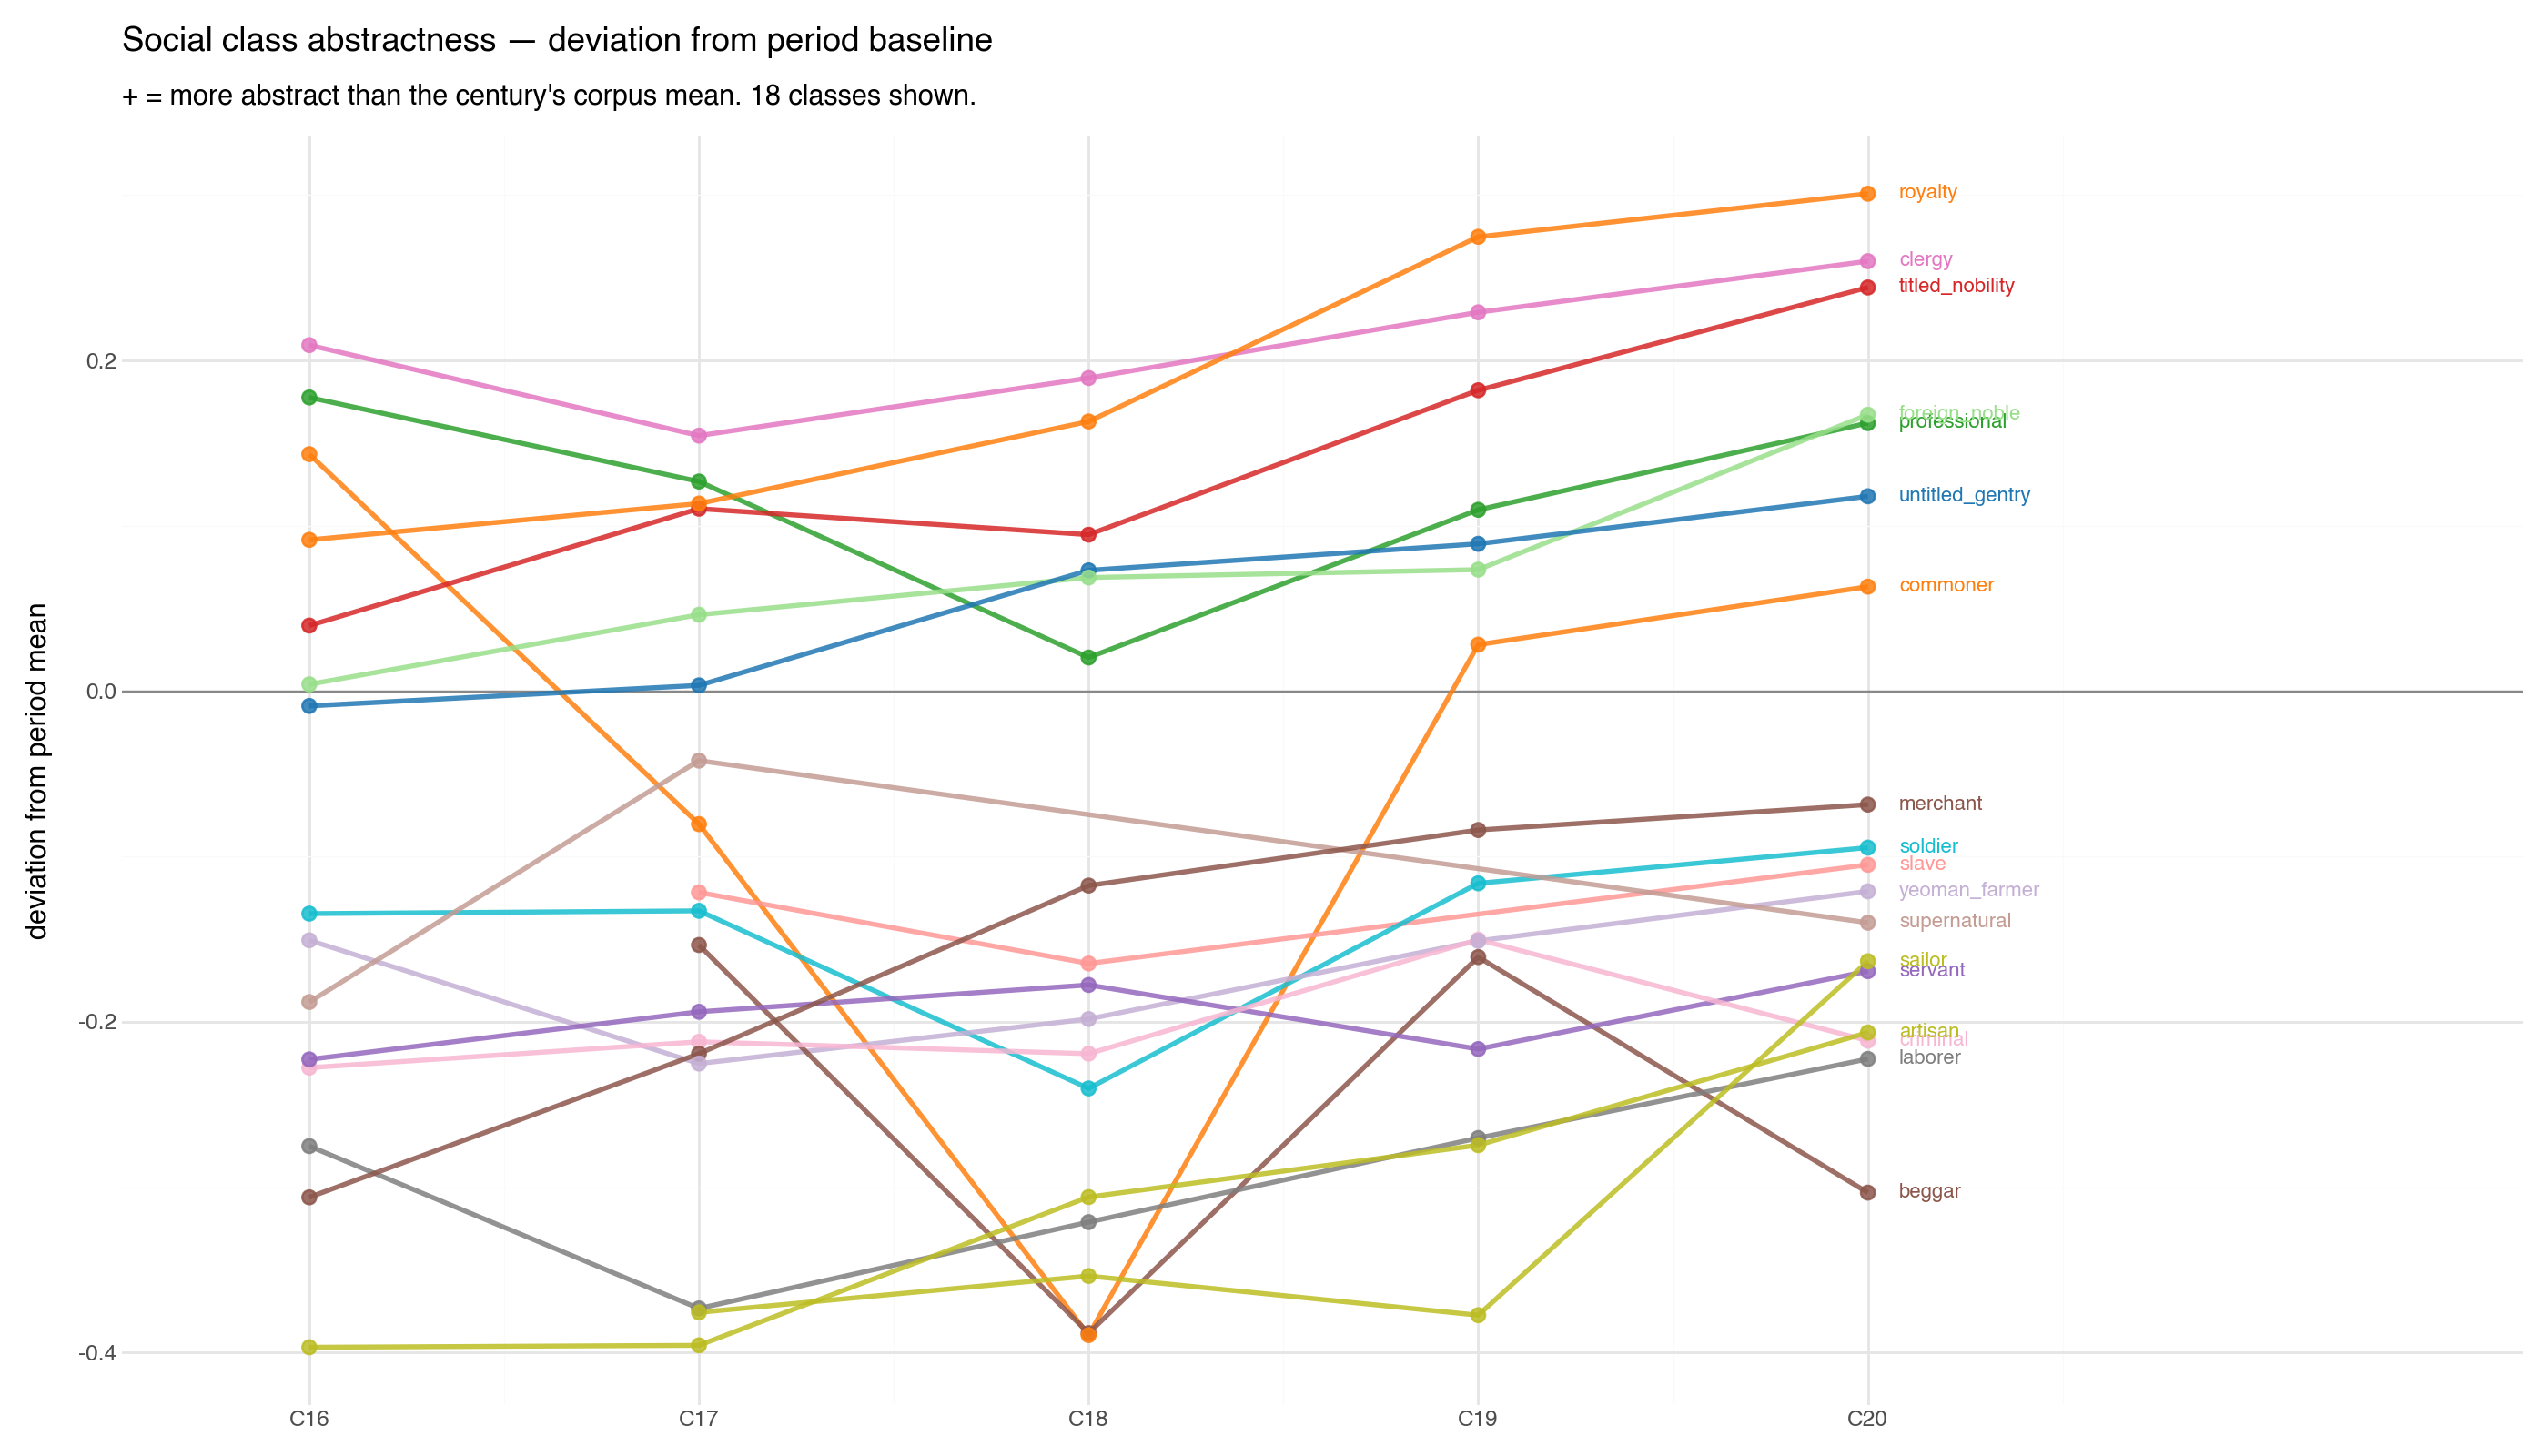

In [7]:
# Period baseline: century mean across all characters with abs+year
period_mean = ch.groupby('century')['char_abs'].mean()
print('Century baseline (corpus mean per century):')
print(period_mean.round(3).to_string())

# --- ARCHETYPE deviation ---
rows_a = []
for arch in expl['archetype'].unique():
    for cent in (1500, 1600, 1700, 1800, 1900):
        sub = expl[(expl['archetype'] == arch) & (expl['century'] == cent)]
        if len(sub) >= 30:
            rows_a.append({
                'archetype': arch, 'century_year': cent + 50,
                'pavel_axis': sub['pavel_axis'].iloc[0],
                'n': len(sub),
                'mean_abs': sub['char_abs'].mean(),
                'baseline': period_mean.loc[cent],
                'dev': sub['char_abs'].mean() - period_mean.loc[cent],
            })
adev = pd.DataFrame(rows_a)
n_cents = adev.groupby('archetype')['century_year'].nunique()
amulti = n_cents[n_cents >= 3].index.tolist()
adev = adev[adev['archetype'].isin(amulti)].copy()
anchor = adev.groupby('archetype')['dev'].first().reindex(amulti)
arch_order = anchor.sort_values(ascending=False).index.tolist()
adev['archetype'] = pd.Categorical(adev['archetype'], categories=arch_order, ordered=True)
alab = adev.sort_values('century_year').groupby('archetype', observed=True, as_index=False).last()
tab10_h = [mcolors.to_hex(c) for c in mcm.tab10.colors]
set2_h = [mcolors.to_hex(c) for c in mcm.Set2.colors]
apal = dict(zip(arch_order, (tab10_h + set2_h + ['#666666','#aaaaaa','#555555'])[:len(arch_order)]))

p_p6a = (p9.ggplot(adev, p9.aes(x='century_year', y='dev',
                                 group='archetype', color='archetype'))
         + p9.geom_hline(yintercept=0, color='#888888', size=0.5)
         + p9.geom_line(size=1.0, alpha=0.85)
         + p9.geom_point(size=2.5, alpha=0.85)
         + p9.geom_text(p9.aes(label='archetype'), data=alab,
                        nudge_x=8, ha='left', size=8, fontweight='bold',
                        show_legend=False)
         + p9.scale_color_manual(values=apal)
         + p9.scale_x_continuous(breaks=[1550,1650,1750,1850,1950],
                                 labels=['C16','C17','C18','C19','C20'],
                                 limits=(1530, 2080))
         + p9.labs(
             title='Archetype abstractness — deviation from period baseline',
             subtitle='+ = more abstract than the century\'s corpus mean; − = more concrete. '
                      'Stable lines = archetype keeps its position; converging lines = archetypes flatten.',
             x='', y='deviation from period mean', color='',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(13, 7), legend_position='none'))
out_a = os.path.join(DROPBOX_FIGS, 'character_types_archetype_deviation.png')
p_p6a.save(out_a, dpi=300, verbose=False)
print(f'\nSaved to {out_a}')
tbl_a = adev.pivot(index='archetype', columns='century_year', values='dev').round(3)
tbl_a.columns = [f'C{(int(c)-50)//100+1}' for c in tbl_a.columns]
tbl_a = tbl_a.reindex(arch_order)
print('\nArchetype deviation from period baseline:')
print(tbl_a.to_string())

# --- CLASS deviation: ALL classes (n>=30 per cell, 3+ centuries) ---
all_classes = [c for c in ch['social_class'].unique() if c not in ('unknown', '')]
print(f'\nAll classes attempted: {len(all_classes)}')

rows_c = []
for cls in all_classes:
    for cent in (1500, 1600, 1700, 1800, 1900):
        sub = ch[(ch['social_class'] == cls) & (ch['century'] == cent)]
        if len(sub) >= 30:
            rows_c.append({
                'social_class': cls, 'century_year': cent + 50,
                'n': len(sub),
                'dev': sub['char_abs'].mean() - period_mean.loc[cent],
            })
cdev = pd.DataFrame(rows_c)
ncc = cdev.groupby('social_class')['century_year'].nunique()
cmulti = ncc[ncc >= 3].index.tolist()
cdev = cdev[cdev['social_class'].isin(cmulti)].copy()
print(f'Classes with n>=30 in 3+ centuries: {len(cmulti)} -> {sorted(cmulti)}')

anchor_c = cdev.groupby('social_class')['dev'].first().reindex(cmulti)
cls_order2 = anchor_c.sort_values(ascending=False).index.tolist()
cdev['social_class'] = pd.Categorical(cdev['social_class'], categories=cls_order2, ordered=True)
clab = cdev.sort_values('century_year').groupby('social_class', observed=True, as_index=False).last()

# Extend PALETTE; auto-fill from tab20 / Set2 for any class without an explicit color
tab20_h = [mcolors.to_hex(c) for c in mcm.tab20.colors]
ext_palette = dict(PALETTE)
for i, cls in enumerate(cls_order2):
    if cls not in ext_palette:
        ext_palette[cls] = tab20_h[i % len(tab20_h)]

p_p6c = (p9.ggplot(cdev, p9.aes(x='century_year', y='dev',
                                 group='social_class', color='social_class'))
         + p9.geom_hline(yintercept=0, color='#888888', size=0.5)
         + p9.geom_line(size=1.1, alpha=0.85)
         + p9.geom_point(size=2.6, alpha=0.85)
         + p9.geom_text(p9.aes(label='social_class'), data=clab,
                        nudge_x=8, ha='left', size=8, fontweight='bold',
                        show_legend=False)
         + p9.scale_color_manual(values=ext_palette)
         + p9.scale_x_continuous(breaks=[1550,1650,1750,1850,1950],
                                 labels=['C16','C17','C18','C19','C20'],
                                 limits=(1530, 2090))
         + p9.labs(
             title='Social class abstractness — deviation from period baseline',
             subtitle=f'+ = more abstract than the century\'s corpus mean. {len(cmulti)} classes shown.',
             x='', y='deviation from period mean', color='',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(14, 8), legend_position='none'))
out_c = os.path.join(DROPBOX_FIGS, 'character_types_class_deviation.png')
p_p6c.save(out_c, dpi=300, verbose=False)
print(f'\nSaved to {out_c}')
tbl_c = cdev.pivot(index='social_class', columns='century_year', values='dev').round(3)
tbl_c.columns = [f'C{(int(c)-50)//100+1}' for c in tbl_c.columns]
tbl_c = tbl_c.reindex(cls_order2)
print('\nClass deviation from period baseline (all 3+century classes):')
print(tbl_c.to_string())

# Range of class deviations per century
print('\nClass-deviation range per century:')
for cent in (1600, 1700, 1800, 1900):
    cy = cent + 50
    devs = cdev[cdev['century_year'] == cy]['dev']
    if len(devs) >= 5:
        print(f'  C{cent//100+1}: range = {devs.max() - devs.min():.3f}  '
              f'(top: {devs.max():+.3f}, bottom: {devs.min():+.3f})')

p_p6c